# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [8]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import math
import kagglehub
import os
import seaborn as sns

C:\Users\minhh\AppData\Local\Temp\ipykernel_29256\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

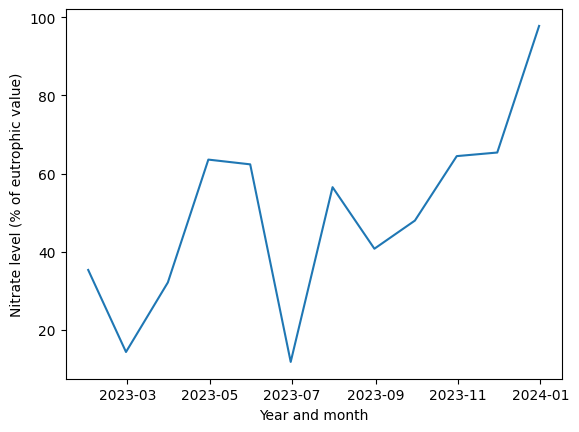

In [9]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\minhh\AppData\Local\Temp\ipykernel_29256\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

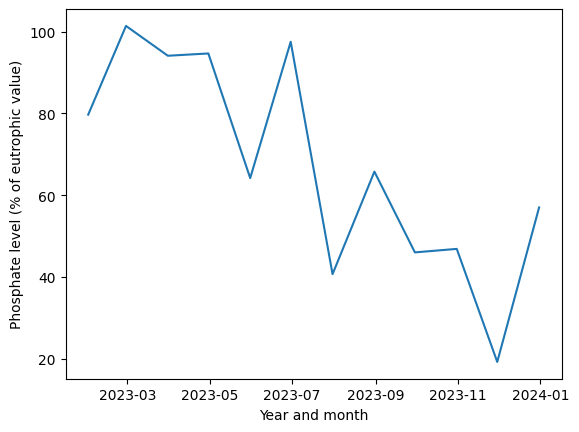

In [10]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

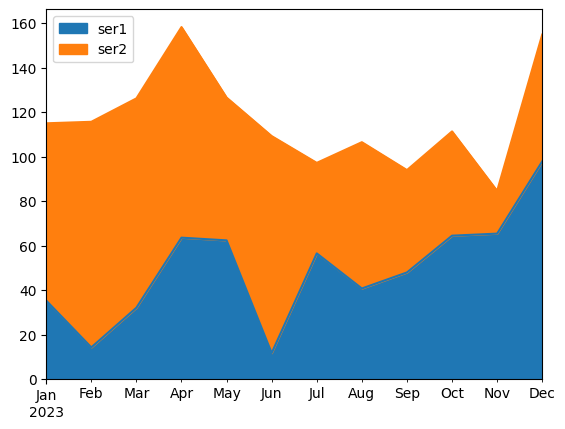

In [11]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Showing it in an area plot can visually reveals the total magnitude over time. It makes it easier to see the cumulative change. Also, it's easy to depict the amount of space the two variables occupy over time. To improve this graph, I would add title and labels with clear units and add gridlines for readability.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

### *Dataset 1: Diabetes Health Indicators*

In [12]:
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

files = os.listdir(path)
df_file = files[0]

df = pd.read_csv(os.path.join(path, df_file))
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### *Age vs Diabetes*

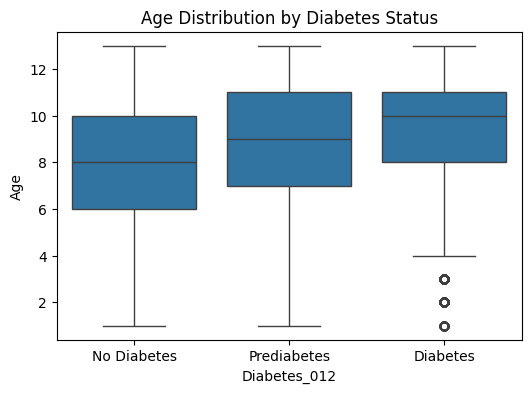

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Diabetes_012", y="Age", data=df)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("Age Distribution by Diabetes Status")
plt.show()

### *Physical Activity vs Diabetes*

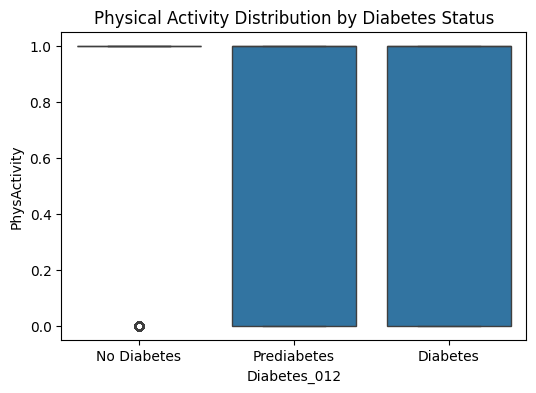

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Diabetes_012", y="PhysActivity", data=df)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("Physical Activity Distribution by Diabetes Status")
plt.show()

### *BMI vs Diabetes*

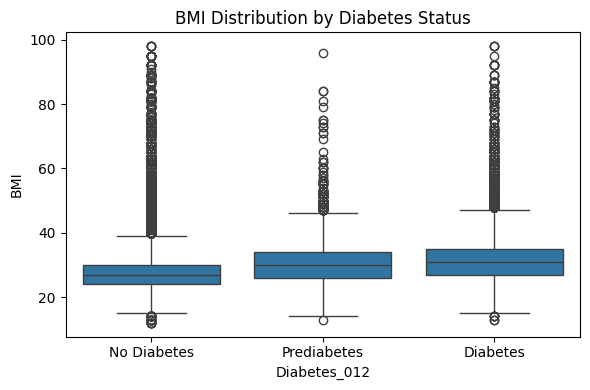

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Diabetes_012", y="BMI", data=df)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("BMI Distribution by Diabetes Status")
plt.tight_layout()
plt.show()

### *Cholesterol level vs Diabetes*

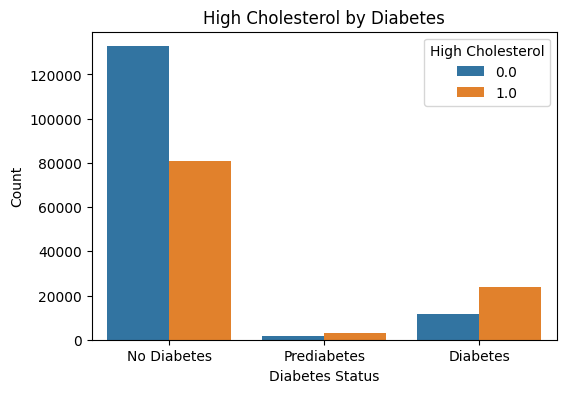

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Diabetes_012",
    hue="HighChol",
    data=df
)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("High Cholesterol by Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")

plt.legend(title="High Cholesterol")
plt.show()

### *Dataset 2: NCHS*

In [33]:
df_nchs = pd.read_csv('https://data.cdc.gov/api/views/w9j2-ggv5/rows.csv?accessType=DOWNLOAD', sep=',')
df_nchs.head(5)

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
0,1900,All Races,Both Sexes,47.3,2518.0
1,1901,All Races,Both Sexes,49.1,2473.1
2,1902,All Races,Both Sexes,51.5,2301.3
3,1903,All Races,Both Sexes,50.5,2379.0
4,1904,All Races,Both Sexes,47.6,2502.5


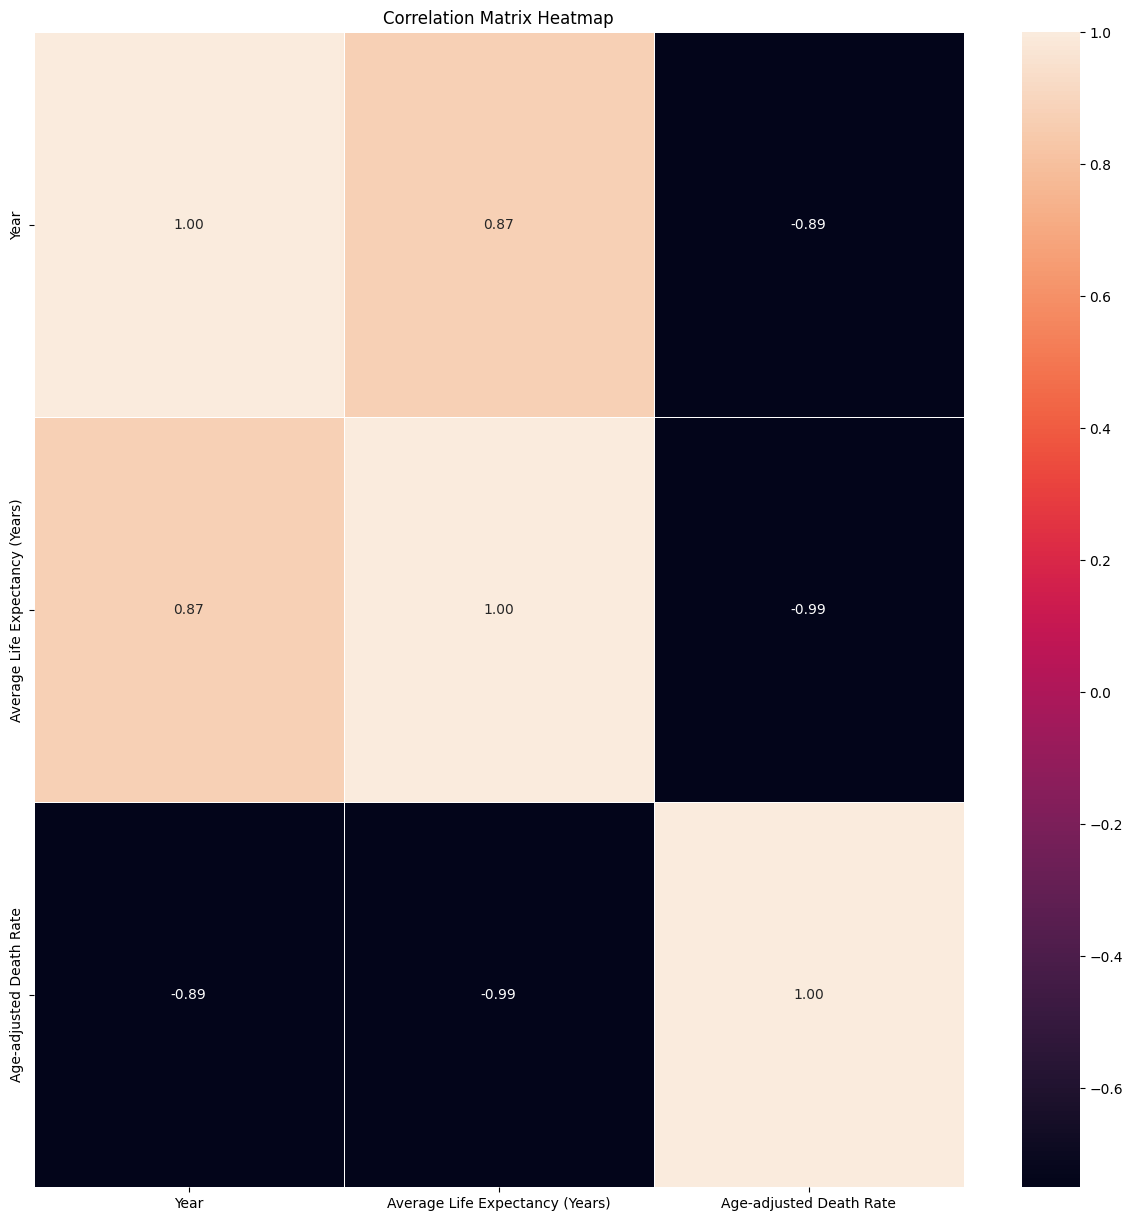

In [36]:
numeric_df = df_nchs.select_dtypes(include=["number"])
corr = numeric_df.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr, 
            annot=True,          
            fmt=".2f",
            vmin=-.75,
            linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

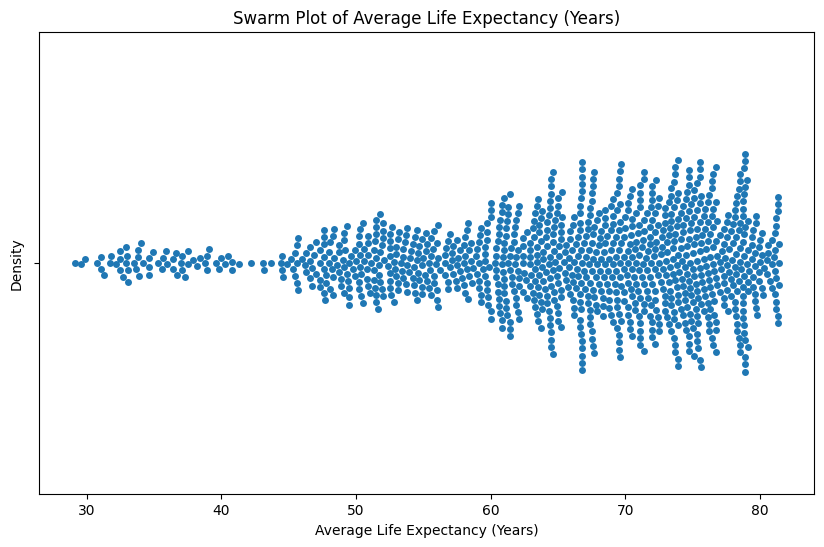

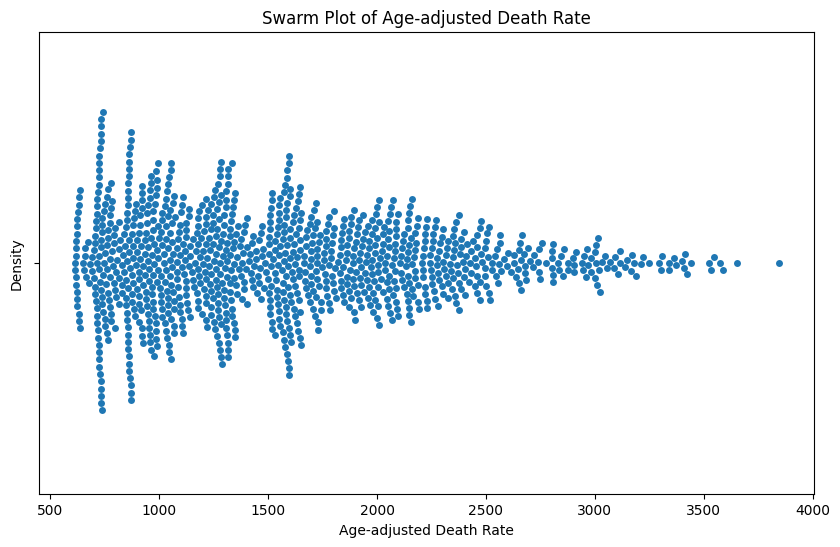

In [41]:
columns = ["Average Life Expectancy (Years)", "Age-adjusted Death Rate"]
# Swarm plot
for c in columns:
    plt.figure(figsize=(10, 6))
    sns.swarmplot(x=numeric_df[c])
    plt.title(f'Swarm Plot of {c}')
    plt.xlabel(c)
    plt.ylabel('Density')
    plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

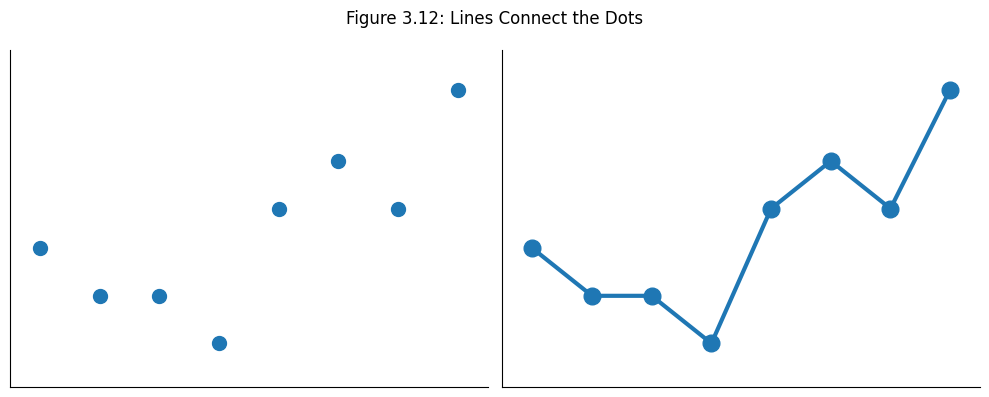

In [22]:
x = np.arange(1, 9)
y = [5, 3.8, 3.8, 2.6, 6, 7.2, 6, 9]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(x, y, s=100)
ax1.set(xlim=(0.5, 8.5), ylim=(1.5, 10))

ax2.plot(x, y, 'o-', markersize=12, linewidth=3)
ax2.set(xlim=(0.5, 8.5), ylim=(1.5, 10))

# Style adjustments
for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

# Titles and labels
fig.suptitle("Figure 3.12: Lines Connect the Dots")

plt.tight_layout()
plt.show()